## TS0: Generador de señales senoidales

La función `mi_funcion_sen` genera una señal de la forma:

$$x(t) = DC + V_{max} \cdot \sin(2\pi f t + \phi)$$

Parámetros:
- `vmax`: amplitud máxima (V)
- `dc`: valor medio o componente continua (V)
- `ff`: frecuencia (Hz)
- `ph`: fase inicial (radianes)
- `nn`: cantidad de muestras
- `fs`: frecuencia de muestreo (Hz)

### Paso 1

Importacion de las librerias a utilizar

In [59]:
import numpy as np
import matplotlib.pyplot as plt

### Paso 2

Defino la funcion *mi_funcion_sen()* con los parametros solicitados en la consigna.
Agrego valores por defecto (en caso de que la utilice sin pasarle un input).

In [60]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

### Paso 3

Utilizo la funcion con los siguientes parametros:

- `vmax = 2` → amplitud máxima de 2 V
- `dc = 0.5` → valor medio de 0.5 V
- `ff = 5` → frecuencia de 5 Hz
- `ph = np.pi/4` → fase de π/4 radianes (45°)
- `nn = N = 1000` → 1000 muestras
- `fs = 1000` → frecuencia de muestreo de 1000 Hz

Realizo grafico de la funcion resultante con libreria => matplotlib.pyplot

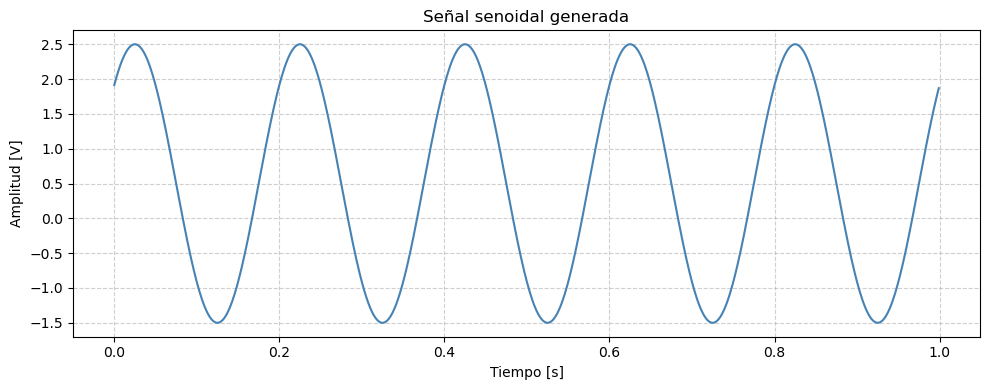

In [61]:
N  = 1000   # número de muestras
fs = 1000   # frecuencia de muestreo [Hz]

tt, xx = mi_funcion_sen(vmax=2, dc=0.5, ff=5, ph=np.pi/4, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Señal senoidal generada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Resultado 1

La funcion  *mi_funcion_sen()* devuelve como resultado:

- tt es el vector de tiempo: Contiene los instantes en segundos en los que el ADC tomó cada muestra
- xx es el vector de la señal: Contiene el valor de tensión (en volts) en cada uno de esos instantes.

En el grafico se puede observar la senal senoidal generada correctamente.

### Bonus 1

Experimentos realizados en clase.

Siguiendo la notacion de la funcion original voy a usar los siguientes parametros fijos:
- `vmax = 1`
- `dc = 0`
- `ph = 0`
- `fs = 1000 Hz`
- `N = 1000`

Y voy a variar unicamente la frecuencia `ff` en cuatro casos: 500, 999, 1001 y 2001 Hz.

En base a la teoria vista en clase, la frecuencia de Nyquist para este sistema es `fs/2 = 500 Hz`, que es el limite teorico a partir del cual el ADC ya no puede representar correctamente una señal.

Por un tema de redundancia en el codigo y ya que solamente cambia la frecuencia en cada experimento voy a usar un bucle for 


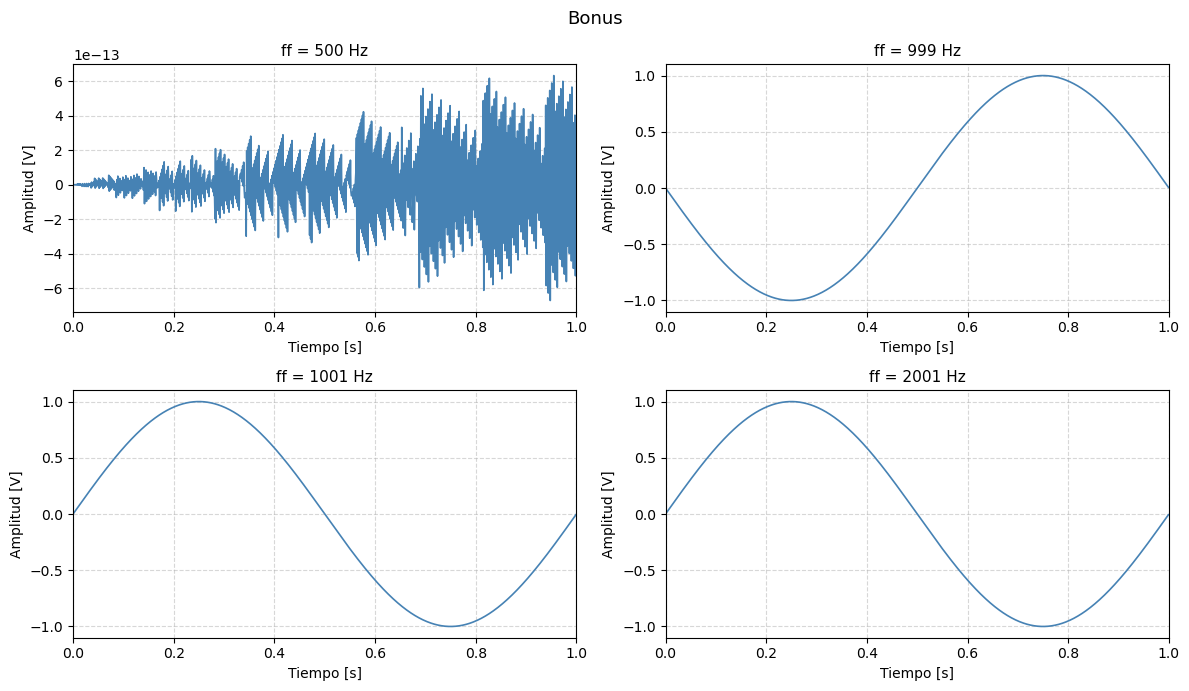

In [62]:
N  = 1000
fs = 1000

frecuencias = [500, 999, 1001, 2001]

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Bonus', fontsize=13)

for ax, ff in zip(axs.flat, frecuencias):
    tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=ff, ph=0, nn=N, fs=fs)
    ax.plot(tt, xx, linewidth=1.2, color='steelblue')
    ax.set_title(f'ff = {ff} Hz', fontsize=11)
    ax.set_xlabel('Tiempo [s]')
    ax.set_ylabel('Amplitud [V]')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim([0, 1])  # Aca hago un zoom en las senales para ver mejor los ciclos

plt.tight_layout()
plt.show()

### Análisis de resultados

- **ff = 500 Hz** (esta frec es fs/2, frecuencia de Nyquist): la amplitud de la senal es muy chica (prácticamente cero). 
Esto ocurre porque con exactamente 2 muestras por 
ciclo y fase cero, todas las muestras caen justo en los cruces por cero de la senoidal.

- **ff = 999 Hz**: se produce **aliasing**. La señal de 999 Hz es indistinguible para el ADC de una señal de 1 Hz, ya que `fs - ff = 1000 - 999 = 1 Hz`. Se observa exactamente un ciclo completo en el segundo graficado.

- **ff = 1001 Hz**: mismo fenómeno. Una señal de 1001 Hz aparece también como 1 Hz (`ff - fs = 1001 - 1000 = 1 Hz`). El gráfico es casi idéntico al caso anterior, con la única diferencia de que la fase está invertida.

- **ff = 2001 Hz**: la señal de 2001 Hz alias igualmente a 1 Hz (`ff - 2*fs = 2001 - 2000 = 1 Hz`). 

Cualquier frecuencia que supere `fs/2` genera aliasing: la señal muestreada aparenta tener una frecuencia completamente distinta a la real, y esa información se pierde de forma irreversible. Por eso el teorema de Nyquist establece que la frecuencia de muestreo debe ser al menos el doble de la frecuencia máxima de la señal.

### Bonus 2

Implemento una señal cuadrada



In [63]:
from scipy.signal import square

def mi_funcion_cuadrada(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, duty=0.5):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    xx = dc + vmax * square(2 * np.pi * ff * tt + ph, duty=duty)
    return tt, xx

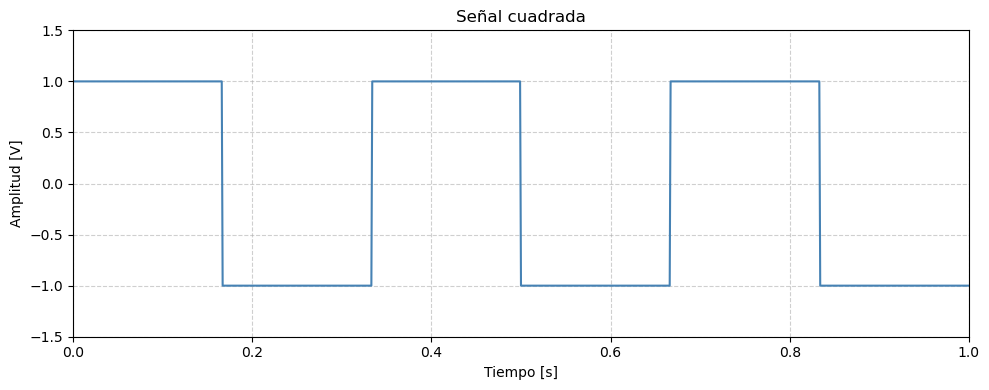

In [64]:
N  = 1000
fs = 1000

tt, xx = mi_funcion_cuadrada(vmax=1, dc=0, ff=3, ph=0, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Señal cuadrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim([-1.5, 1.5])
plt.xlim([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Bonus 3

Implemento una señal Pulso Gaussiano

In [65]:
from scipy.signal import gausspulse

def mi_funcion_gausspulse(vmax=1, dc=0, fc=10, bw=0.5, nn=1000, fs=1000):
    tt = (np.arange(nn) / fs).reshape(nn, 1)
    t_centered = tt - tt.mean()
    xx = dc + vmax * gausspulse(t_centered, fc=fc, bw=bw)
    return tt, xx

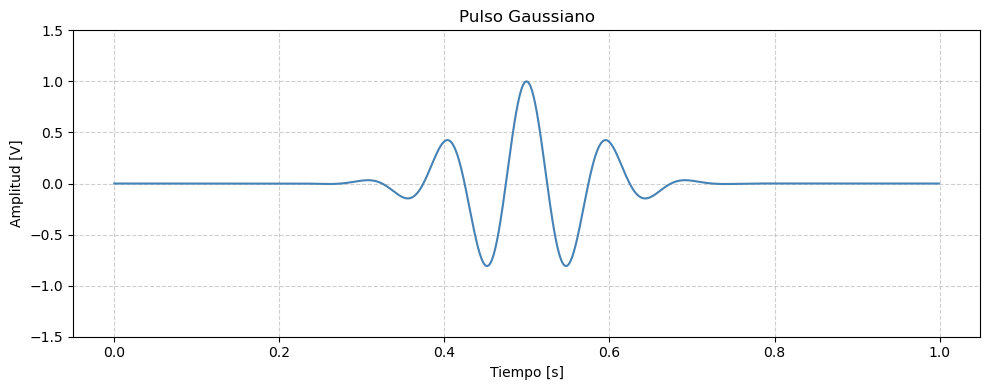

In [66]:
N  = 1000
fs = 1000

tt, xx = mi_funcion_gausspulse(vmax=1, dc=0, fc=10, bw=0.5, nn=N, fs=fs)

plt.figure(figsize=(10, 4))
plt.plot(tt, xx, linewidth=1.5, color='steelblue')
plt.title('Pulso Gaussiano')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.ylim([-1.5, 1.5])
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()